<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_8_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df = pd.read_csv("/content/studyhours_large.csv")

In [78]:
df.head()

,Study Hours,Exam Score
0,2.4,51.5
1,2.4,42.4
2,2.4,44.1
3,2.7,44.6
4,2.7,36.6


In [79]:
df.tail()

,Study Hours,Exam Score
155,30.6,100.0
156,31.5,100.0
157,31.5,100.0
158,31.5,100.0
159,32.1,100.0


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  160 non-null    float64
 1   Exam Score   160 non-null    float64
dtypes: float64(2)
memory usage: 2.6 KB


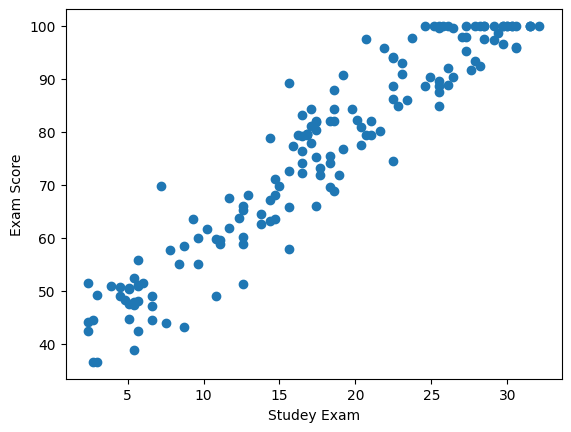

In [81]:
plt.scatter(df['Study Hours'],df['Exam Score'])
plt.xlabel("Studey Exam")
plt.ylabel("Exam Score")
plt.show()

In [82]:
#independent and dependent features - bağımlı ve bağımsız değişken
X=df[['Study Hours']] # dataframe olarak verilmeli
y=df['Exam Score'] #series olarak verilmeli.

In [83]:
type(X)

pandas.core.frame.DataFrame

In [84]:
type(y)

pandas.core.series.Series

In [85]:
from sklearn.model_selection import train_test_split

In [86]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=15)

In [87]:
y_train

,Exam Score
58,71.2
57,68.1
137,93.4
55,63.2
47,58.8
...,...
155,100.0
128,100.0
119,84.8
133,100.0


In [88]:
y_test

,Exam Score
158,100.0
63,72.7
40,58.9
31,55.0
117,90.4
74,81.1
130,99.6
142,97.6
111,93.0
25,49.0


In [89]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 32 entries, 158 to 145
Series name: Exam Score
Non-Null Count  Dtype  
--------------  -----  
32 non-null     float64
dtypes: float64(1)
memory usage: 512.0 bytes


In [90]:
#Standardize the dataset - datayı standartize etme
from sklearn.preprocessing import StandardScaler

In [91]:
scaler=StandardScaler()

In [92]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

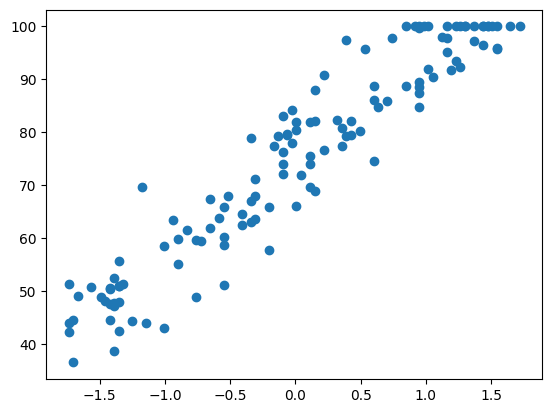

In [93]:
plt.scatter(X_train,y_train)
plt.show() # datamızın görüntüsü değişmedi ama x eksenine bakarsanız büyüklükler belli bir aralığa geldi ve küçüldü.

In [94]:
X_test #Standardize ettiğimiz için datalar değişmedi ama bellirli bir aralığa indirgendi.

array([[ 1.64772409],
       [-0.20235208],
       [-0.72595854],
       [-1.04012242],
       [ 0.87976794],
       [-0.02781659],
       [ 1.05430343],
       [ 1.29865311],
       [ 0.67032536],
       [-1.24956501],
       [-1.49391469],
       [-0.09763079],
       [ 0.0070905 ],
       [ 0.67032536],
       [-1.24956501],
       [ 0.28634728],
       [-0.55142306],
       [ 0.18162599],
       [ 1.64772409],
       [-1.66845018],
       [-0.20235208],
       [ 1.01939633],
       [ 0.60051116],
       [ 1.5080957 ],
       [ 0.60051116],
       [ 0.0419976 ],
       [-0.27216628],
       [-1.10993662],
       [ 0.0070905 ],
       [-0.06272369],
       [ 0.14671889],
       [ 1.4033744 ]])

In [95]:
from sklearn.linear_model import LinearRegression

In [96]:
regression = LinearRegression()

In [97]:
regression.fit(X_train,y_train)

LinearRegression()

In [98]:
print("coefficient :", regression.coef_)
print("Intercept", regression.intercept_) # y = 74.73 + 18.19 x

coefficient : [18.19916299]
Intercept 74.7375


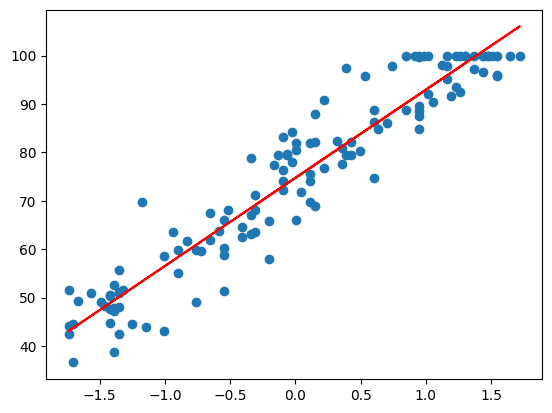

In [99]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),"r")
plt.show()

In [100]:
y_pred_test = regression.predict(X_test)

In [101]:
y_test

,Exam Score
158,100.0
63,72.7
40,58.9
31,55.0
117,90.4
74,81.1
130,99.6
142,97.6
111,93.0
25,49.0


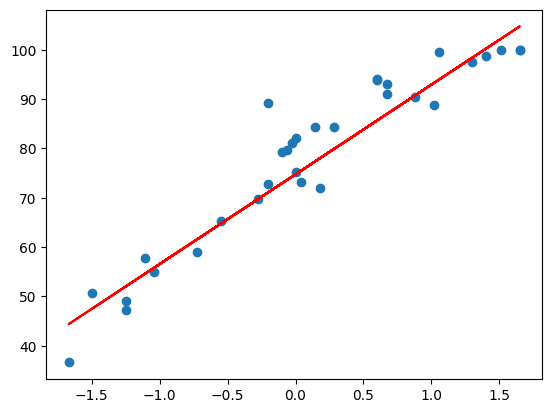

In [102]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regression.predict(X_test),"r")
plt.show()

In [103]:
#performance Metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [104]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

32.41592181218445
4.489797203327686
5.693498205162135


In [105]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)

In [106]:
score

0.8964372361295354

In [107]:
#yeni bir öğrenci geldi kaç alır.

In [109]:
scaler.transform([[5]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-1.43573619]])

In [110]:
regression.predict(scaler.transform([[5]]))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([48.60830301])